# LightGBM Regressor
Trains a LightGBM regressor to predict `log_return` with a time-based validation split for early stopping, saving artifacts and generating plots.

In [1]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

# Handle paths based on execution directory
if Path.cwd().name == 'notebooks':
    base_dir = Path('..')
else:
    base_dir = Path('.')

data_dir = base_dir / 'data' / 'processed'
assets_dir = base_dir / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)

train_path = data_dir / 'train.csv'
test_path = data_dir / 'test.csv'

print(f"Reading data from: {data_dir}")
print(f"Assets will be saved to: {assets_dir}")

Reading data from: ../data/processed
Assets will be saved to: ../assets


## 1. Load Data & Validation Split
We use a time-based split of `train.csv` to create a validation set for early stopping.

In [2]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])

# Ensure chronological order
train_df = train_df.sort_values(['RegionID', 'date']).reset_index(drop=True)
test_df = test_df.sort_values(['RegionID', 'date']).reset_index(drop=True)

features = ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'city_enc']
target = 'log_return'

# Validation strategy: use the last 15% of unique dates in the training set
unique_dates = train_df['date'].sort_values().unique()
split_idx = int(len(unique_dates) * 0.85)
split_date = unique_dates[split_idx]

train_subset = train_df[train_df['date'] < split_date]
val_subset = train_df[train_df['date'] >= split_date]

print(f"Training set size: {len(train_subset)}")
print(f"Validation set size: {len(val_subset)}")

X_train_sub = train_subset[features]
y_train_sub = train_subset[target]
X_val = val_subset[features]
y_val = val_subset[target]

X_test = test_df[features]
y_test = test_df[target]

Training set size: 179694
Validation set size: 32184


## 2. Feature Scaling

In [3]:
scaler = StandardScaler()
X_train_sub_scaled = scaler.fit_transform(X_train_sub)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for LightGBM feature names later
X_train_sub_scaled = pd.DataFrame(X_train_sub_scaled, columns=features)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=features)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features)

## 3. Train LightGBM Model

In [4]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

# Callbacks for early stopping
callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)]

model.fit(
    X_train_sub_scaled, y_train_sub,
    eval_set=[(X_val_scaled, y_val)],
    eval_metric='l2',  # MSE as evaluation metric
    callbacks=callbacks
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001119 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1530
[LightGBM] [Info] Number of data points in the train set: 179694, number of used features: 6
[LightGBM] [Info] Start training from score 0.001460
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[211]	valid_0's l2: 7.21175e-06


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 4. Feature Importance & Export

Feature importance plot saved to: ../assets/feature_importance.png


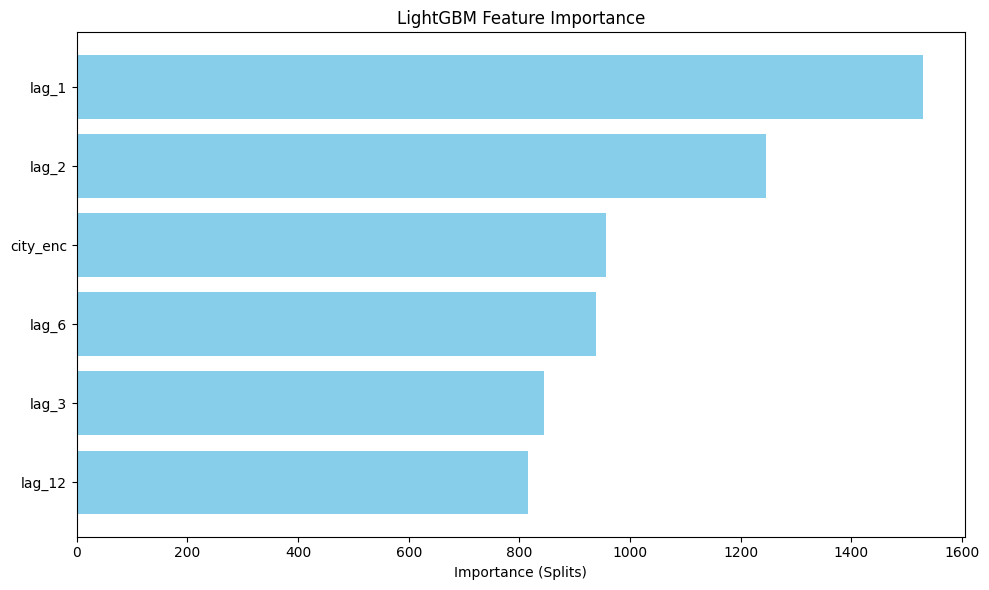

Model and scaler saved to ../assets


In [5]:
importance = model.feature_importances_
importance_df = pd.DataFrame({'Feature': features, 'Importance': importance}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance (Splits)')
plt.tight_layout()

feature_imp_path = assets_dir / 'feature_importance.png'
plt.savefig(feature_imp_path, dpi=300)
print(f"Feature importance plot saved to: {feature_imp_path}")
plt.show()

# Export artifacts
model_path = assets_dir / 'housing_model.pkl'
scaler_path = assets_dir / 'scaler.pkl'
joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
print(f"Model and scaler saved to {assets_dir}")

## 5. Visualization: Actual vs. Predicted Price

[LightGBM] log_return - MAE: 0.002166 | RMSE: 0.003001 | R2: 0.853533
[LightGBM] Price Space - MAE: $543.87 | RMSE: $937.00 | R2: 0.999967

Visualization saved to: ../assets/price_predictions_vs_actual.png


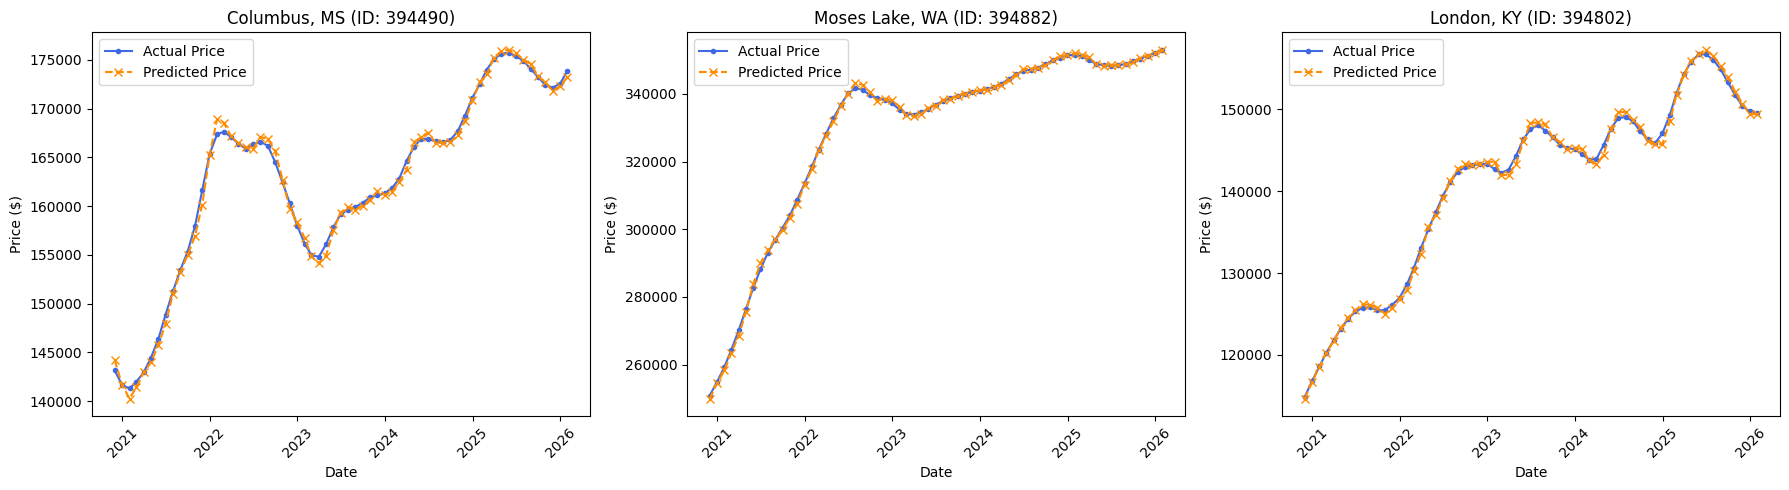

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reconstruct actual previous prices in the test set
test_df['price_prev'] = test_df['price'] / np.exp(test_df['log_return'])

# Predict test set log returns
test_preds_log = model.predict(X_test_scaled)

lgb_log_mae = mean_absolute_error(y_test, test_preds_log)
lgb_log_rmse = np.sqrt(mean_squared_error(y_test, test_preds_log))
lgb_log_r2 = r2_score(y_test, test_preds_log)

# Transform predictions to actual prices
test_df['predicted_price'] = test_df['price_prev'] * np.exp(test_preds_log)

lgb_price_mae = mean_absolute_error(test_df['price'], test_df['predicted_price'])
lgb_price_rmse = np.sqrt(mean_squared_error(test_df['price'], test_df['predicted_price']))
lgb_price_r2 = r2_score(test_df['price'], test_df['predicted_price'])

result_str = f"[LightGBM] log_return - MAE: {lgb_log_mae:.6f} | RMSE: {lgb_log_rmse:.6f} | R2: {lgb_log_r2:.6f}\n"
result_str += f"[LightGBM] Price Space - MAE: ${lgb_price_mae:,.2f} | RMSE: ${lgb_price_rmse:,.2f} | R2: {lgb_price_r2:.6f}\n"
print(result_str)

# Save metrics to assets
with open(assets_dir / 'lightgbm_metrics.txt', 'w') as f:
    f.write(result_str)

# Pick 3 random RegionIDs
np.random.seed(123)
random_regions = np.random.choice(test_df['RegionID'].unique(), 3, replace=False)

plt.figure(figsize=(18, 5))
for i, region in enumerate(random_regions, 1):
    region_data = test_df[test_df['RegionID'] == region].sort_values('date')
    
    plt.subplot(1, 3, i)
    plt.plot(region_data['date'], region_data['price'], label='Actual Price', marker='.', color='royalblue')
    plt.plot(region_data['date'], region_data['predicted_price'], label='Predicted Price', marker='x', linestyle='--', color='darkorange')
    
    region_name = region_data['RegionName'].iloc[0]
    plt.title(f"{region_name} (ID: {region})")
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.xticks(rotation=45)
    plt.legend()

plt.tight_layout()
visualization_path = assets_dir / 'price_predictions_vs_actual.png'
plt.savefig(visualization_path, dpi=300)
print(f"Visualization saved to: {visualization_path}")
plt.show()
